<a href="https://colab.research.google.com/github/SRIJANRAOS/srijanraos_INFO5731_spring2026/blob/main/Sentiment_analysis_python_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis in Python

Sentiment analysis is the use of Natural Language Processing to identify the emotions behind the text.

In this notebook we will be doing some sentiment analysis in python using two different techniques:
1. VADER (Valence Aware Dictionary and sEntiment Reasoner) - Bag of words approach
2. Roberta Pretrained Model from Hugging Face🤗
3. Huggingface Pipeline

# Step 0. Read in Data and NLTK Basics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk

In [2]:
from google.colab import files
uploaded = files.upload()

Saving 1000reviews-1.csv to 1000reviews-1.csv


Dataset:
https://www.kaggle.com/code/robikscube/sentiment-analysis-python-youtube-tutorial/notebook

In [4]:
df = pd.read_csv('1000reviews-1.csv')
print(df.shape)
#down sampling the dataset as its too large
df = df.head(500)
print(df.shape)

(1039, 10)
(500, 10)


In [21]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1300000000,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1350000000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1220000000,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1310000000,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350000000,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df['Text'].values[0:2]

array(['I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.',
       'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".'],
      dtype=object)

## Quick exploratory data analysis (EDA)

Rating from 1 to 5

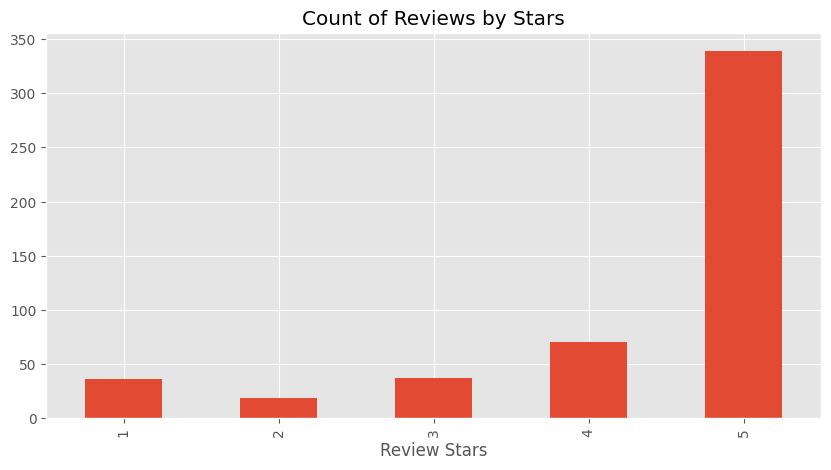

In [6]:
ax = df['Score'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5))
ax.set_xlabel('Review Stars')
plt.show()

## Basic NLTK

In [7]:
example = df['Text'][50]
print(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


Tokenization

In [10]:
nltk.download('punkt')
nltk.download('punkt_tab')
tokens = nltk.word_tokenize(example)
tokens[:10]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['This', 'oatmeal', 'is', 'not', 'good', '.', 'Its', 'mushy', ',', 'soft']

Part of Speech Tagging : https://www.guru99.com/pos-tagging-chunking-nltk.html

In [16]:
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
tagged = nltk.pos_tag(tokens)
tagged[:10]

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


[('This', 'DT'),
 ('oatmeal', 'NN'),
 ('is', 'VBZ'),
 ('not', 'RB'),
 ('good', 'JJ'),
 ('.', '.'),
 ('Its', 'PRP$'),
 ('mushy', 'NN'),
 (',', ','),
 ('soft', 'JJ')]

In [22]:
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('maxent_ne_chunker_tab')
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


(S
  This/DT
  oatmeal/NN
  is/VBZ
  not/RB
  good/JJ
  ./.
  Its/PRP$
  mushy/NN
  ,/,
  soft/JJ
  ,/,
  I/PRP
  do/VBP
  n't/RB
  like/VB
  it/PRP
  ./.
  (ORGANIZATION Quaker/NNP Oats/NNPS)
  is/VBZ
  the/DT
  way/NN
  to/TO
  go/VB
  ./.)


# Step 1. VADER Sentiment Scoring

We will use NLTK's `SentimentIntensityAnalyzer` to get the neg/neu/pos scores of the text.

- This uses a "bag of words" approach:
    1. Stop words are removed
    2. each word is scored and combined to a total score.

In [23]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [24]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm #for progress bar tracker

# Sentiment  Intensity Analyzer object to run on different texts
sia = SentimentIntensityAnalyzer()

In [33]:
#compound ranges from -1 (most negative) to +1 (most positive).

In [40]:
new_example = "This is a fantastic product! I love it."
print(new_example)
sia.polarity_scores(new_example)

This is a fantastic product! I love it.


{'neg': 0.0, 'neu': 0.331, 'pos': 0.669, 'compound': 0.8439}

In [28]:
# Run the polarity score on the entire dataset
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/500 [00:00<?, ?it/s]

In [34]:
vaders = pd.DataFrame(res).T # transpose to get the output in the original format
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, how='left')

In [35]:
# Now we have sentiment score and metadata
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1300000000,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1350000000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1220000000,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1310000000,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350000000,Great taffy,Great taffy at a great price. There was a wid...


In [30]:
df['Text'].values[0:4]

array(['I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.',
       'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".',
       'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.',
    

## Plot VADER results

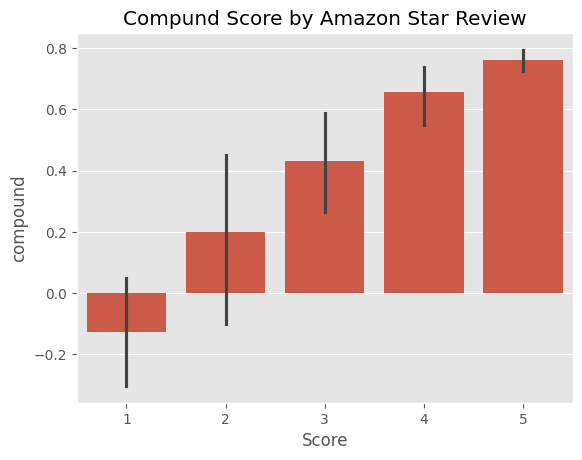

In [36]:
ax = sns.barplot(data=vaders, x='Score', y='compound')
ax.set_title('Compund Score by Amazon Star Review')
plt.show()

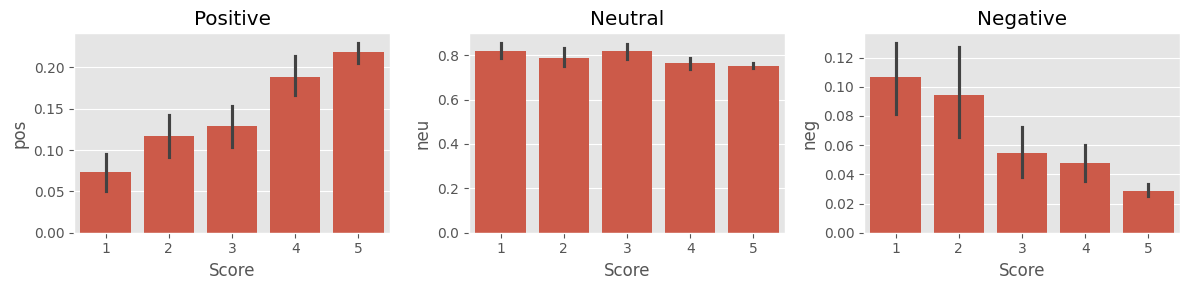

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='Score', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Score', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Score', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()


# Step 2. Roberta Pretrained Model

- Use a model trained of a large corpus of data.
- Transformer model accounts for the words but also the context related to other words.

In [38]:
!pip install transformers

In [39]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

Roberata: https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment

When we run the **AutoTokenizer** and **AutoModelForSequenceClassification** methods and load it from a pre-trained model, it will pull down the model weights that have been store.

Transfer learning

In [41]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Traditional Approach Results

In [42]:
# VADER results on example
print(example)
sia.polarity_scores(example)

This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.


{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [43]:
# Run for Roberta Model
#encoding the text. pt is for pytorch. Convert into 0s and 1s embeddings that the model will understand
encoded_text = tokenizer(example, return_tensors='pt')

#Execute the model
output = model(**encoded_text)
print(output)

#Storing the output in numpy locally
scores = output[0][0].detach().numpy()

#Apply Softmax layer to scale the scores between 0 and 1
scores = softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

SequenceClassifierOutput(loss=None, logits=tensor([[ 3.1436, -0.7107, -2.6559]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)
{'roberta_neg': np.float32(0.97635514), 'roberta_neu': np.float32(0.020687465), 'roberta_pos': np.float32(0.0029573692)}


Compare the Results of Vader model and Roberta Model

Vader: {'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

Roberta: {'roberta_neg': 0.97635514, 'roberta_neu': 0.020687476, 'roberta_pos': 0.002957372}

In [44]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [45]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = row['Text']
        myid = row['Id']
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both
    except RuntimeError:
        print(f'Broke for id {myid}')

  0%|          | 0/500 [00:00<?, ?it/s]

Broke for id 83
Broke for id 187


In [46]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')

In [47]:
results_df.head()

,Id,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,0.009624,0.049980,0.940395,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1300000000,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,0.508986,0.452414,0.038600,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1350000000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,0.003229,0.098067,0.898704,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1220000000,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,0.002295,0.090219,0.907486,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1310000000,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,0.001635,0.010302,0.988063,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350000000,Great taffy,Great taffy at a great price. There was a wid...


## Compare Scores between models

In [48]:
results_df.columns

Index(['Id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'ProductId', 'UserId',
       'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
       'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

# Step 3. Combine and compare

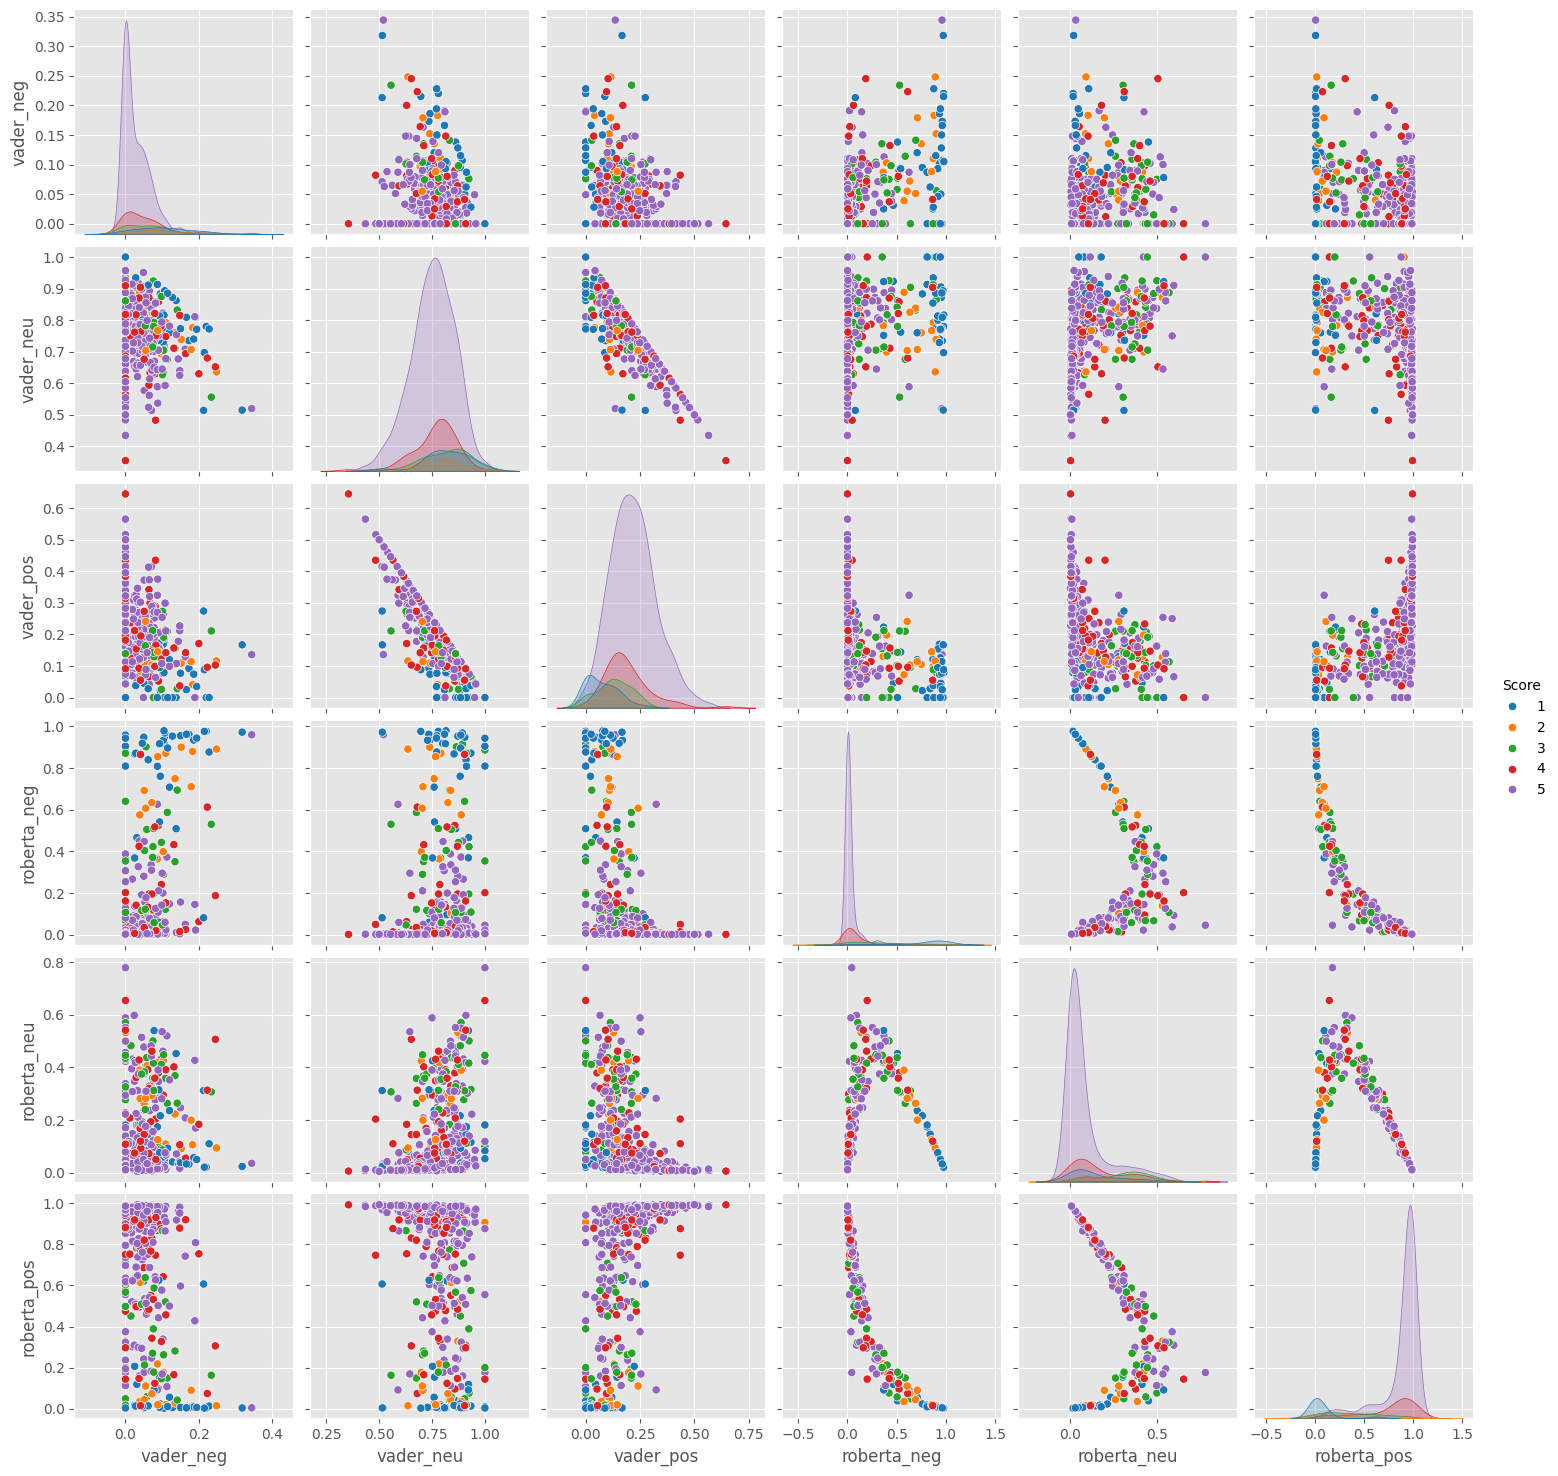

In [49]:
sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='Score',
            palette='tab10')
plt.show()

# Step 4: Review Examples:

- Positive 1-Star and Negative 5-Star Reviews

Lets look at some examples where the model scoring and review score differ the most.

Highest positivity score with rating 1 by Roberta Model

In [50]:
results_df.query('Score == 1') \
    .sort_values('roberta_pos', ascending=False)['Text'].values[0]

'I felt energized within five minutes, but it lasted for about 45 minutes. I paid $3.99 for this drink. I could have just drunk a cup of coffee and saved my money.'

Highest positivity score with rating 1 by Vader Model

In [51]:
results_df.query('Score == 1') \
    .sort_values('vader_pos', ascending=False)['Text'].values[0]

'So we cancelled the order.  It was cancelled without any problem.  That is a positive note...'

In [52]:
# negative sentiment 5-Star view

In [53]:
results_df.query('Score == 5') \
    .sort_values('roberta_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

In [54]:
results_df.query('Score == 5') \
    .sort_values('vader_neg', ascending=False)['Text'].values[0]

'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault'

# The Transformers Pipeline
- Quick & easy way to run sentiment predictions

In [55]:
from transformers import pipeline

sent_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [56]:
sent_pipeline('I love sentiment analysis!')

[{'label': 'POSITIVE', 'score': 0.9997853636741638}]

In [57]:
sent_pipeline('booo')

[{'label': 'NEGATIVE', 'score': 0.9936267137527466}]

In [58]:

sent_pipeline('this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault')

[{'label': 'NEGATIVE', 'score': 0.9980344176292419}]

#GPT for SentimentAnalysis

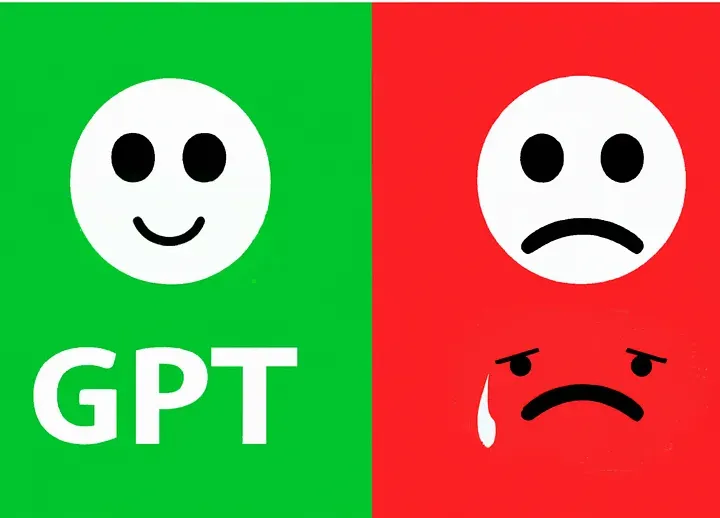

Paper: https://paperswithcode.com/task/aspect-based-sentiment-analysis

Github Repository: https://github.com/ScalaConsultants/Aspect-Based-Sentiment-Analysis

Sentiment Analysis with GPT-3 and GPT-3.5:
https://archive.is/m0dcF#selection-791.0-809.115

How to apply OpenAI API

Create an API key in the dashboard here (https://platform.openai.com/api-keys), which you’ll use to securely access the API. Store the key in a safe location, like a .zshrc file or another text file on your computer. Once you’ve generated an API key, export it as an environment variable in your terminal.

1. Method 1

Recognize all aspect terms with their corresponding sentiment polarity in the given review delimited by triple quotes. The aspect terms are nouns or phrases appearing in the review that indicate specific aspects or  features of the product/service. Determine the sentiment polarity from the options [\"positive\", \"negative\", \"neutral\"]. Answer in the format [\"aspect\", \"sentiment\"] without any explanation. If no aspect term exists, then only answer \"[]\"."

Text: Recently visited The Leela Palace for a staycation and it was the best. Set amidst lush green and perfectly landscaped gardens, it indeed is a palace. But what makes it even more special is the feeling you stay there. The architecture of the hotel is fascinating and it is a perfect getaway well within the city. It has the feel of a heritage stay and is the best for celebrating special occasions. The staff goes out of their way to make your stay comfortable and memorable.
The interiors are beautiful and plush and the rooms are spacious with all modern amenities that you would need. The suites are huge with a living room and a grand bedroom with balconies that open up to a beautiful view.
Our check-in was quick and really impressed to see how well they are managing covid protocols.
Coming to the food, we dined at Citrus, Zen and Jamavar which is their iconic Indian restaurant. The breakfast buffet was quite exhaustive will dishes for all tastes. Lunch and dinner had multi cuisine dishes in Citrus. Zen is the oriental restaurant and highly recommend their dimsums and sushi. My personal favourite is Jamavar which serves the best Indian food in town.
Our staycation was made even more special by the friendliness and service of the whole team. It's a very kid-friendly hotel and highly recommend it for family staycations.
The surrrounding was dirty and messy.

2. Method 2

In [ ]:
%%capture
# update or install the necessary libraries
!pip install --upgrade openai
!pip install --upgrade langchain
!pip install --upgrade python-dotenv
!pip install --upgrade chromadb
!pip install tiktoken

In [ ]:
import openai

# Define API key
client = OpenAI(
            # Put your_api_key here
            api_key = "sk-proj-HS6aYq2JxOh6kNO4wpdK0kfJPVLfJEGg1Ui-x0-19YxMfIfP2wgp230AgNryNKP4W0Fy_nRXrjGUA"
        )


# Define function to call the API
def analyze_aspects(text):
    # Generate the prompt
    prompt = generate_prompt(text)

    # Call the GPT API
    response = client.chat.completions.create(
        model="gpt-4",  # or "gpt-3.5-turbo", depending on the desired model
        messages=[
            {"role": "system", "content": "You are a helpful assistant for analyzing aspect terms."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=200,
        n=1,
        stop=None,
        temperature=0
    )

    # Retrieve and return the response content
    return response.choices[0].message.content

# Define prompt template
def generate_prompt(text):
    template =  """
              Recognize all aspect terms with their corresponding sentiment polarity in the given review delimited by triple quotes. The aspect terms are nouns or phrases appearing in the review that indicate specific aspects or
              features of the product/service. Determine the sentiment polarity from the options [\"positive\", \"negative\", \"neutral\"]. Answer in the format [\"aspect\", \"sentiment\"] without any explanation. If no aspect
              term exists, then only answer \"[]\"."
               ```{text}```
           """
    return template.format(text=text)

# Example call
text = """

A five-seater SUV with an amazing variety of features, the Tata Nexon is priced impressively between Rs. 7.80 to 14.50 lakhs*.
It provides a wide range of customization possibilities with 65 versions, two engine choices, and two gearbox options.
It is a well-liked option in its market thanks to its svelte look and strong performance.
There is plenty of room for passengers and baggage in the Nexon's large cabin and 350-litre trunk. It can comfortably navigate rocky roads and terrain thanks to its 209 mm ground clearance. The Tata Nexon is a sleek and functional SUV for both families and adventurers, and it comes in nine appealing colours.
"""

result = analyze_aspects(text)
print(result)

["five-seater SUV", "positive"], ["variety of features", "positive"], ["Tata Nexon", "positive"], ["price", "positive"], ["customization possibilities", "positive"], ["65 versions", "positive"], ["two engine choices", "positive"], ["two gearbox options", "positive"], ["svelte look", "positive"], ["strong performance", "positive"], ["room for passengers and baggage", "positive"], ["large cabin", "positive"], ["350-litre trunk", "positive"], ["209 mm ground clearance", "positive"], ["sleek and functional SUV", "positive"], ["nine appealing colours", "positive"]


Prompts taken from: https://rafalrolczynski.com/2021/03/07/aspect-based-sentiment-analysis/

In [ ]:
text="""
Recently visited The Leela Palace for a staycation and it was the best. Set amidst lush green and perfectly landscaped gardens, it indeed is a palace. But what makes it even more special is the feeling you stay there. The architecture of the hotel is fascinating and it is a perfect getaway well within the city. It has the feel of a heritage stay and is the best for celebrating special occasions. The staff goes out of their way to make your stay comfortable and memorable.
The interiors are beautiful and plush and the rooms are spacious with all modern amenities that you would need. The suites are huge with a living room and a grand bedroom with balconies that open up to a beautiful view.
Our check-in was quick and really impressed to see how well they are managing covid protocols.
Coming to the food, we dined at Citrus, Zen and Jamavar which is their iconic Indian restaurant. The breakfast buffet was quite exhaustive will dishes for all tastes. Lunch and dinner had multi cuisine dishes in Citrus. Zen is the oriental restaurant and highly recommend their dimsums and sushi. My personal favourite is Jamavar which serves the best Indian food in town.
Our staycation was made even more special by the friendliness and service of the whole team. It's a very kid-friendly hotel and highly recommend it for family staycations.
The surrrounding was dirty and messy.
"""
result = analyze_aspects(text)
print(result)


["The Leela Palace", "positive"], ["lush green and perfectly landscaped gardens", "positive"], ["architecture of the hotel", "positive"], ["heritage stay", "positive"], ["staff", "positive"], ["interiors", "positive"], ["rooms", "positive"], ["modern amenities", "positive"], ["suites", "positive"], ["balconies", "positive"], ["beautiful view", "positive"], ["check-in", "positive"], ["covid protocols", "positive"], ["food", "positive"], ["Citrus", "positive"], ["Zen", "positive"], ["Jamavar", "positive"], ["breakfast buffet", "positive"], ["lunch and dinner", "positive"], ["dimsums and sushi", "positive"], ["Indian food", "positive"], ["friendliness and service of the whole team", "positive"], ["kid-friendly hotel", "positive"], ["family staycations", "positive"], ["surrrounding", "negative"]


#**BERTopic - Dynamic Topic Modeling**

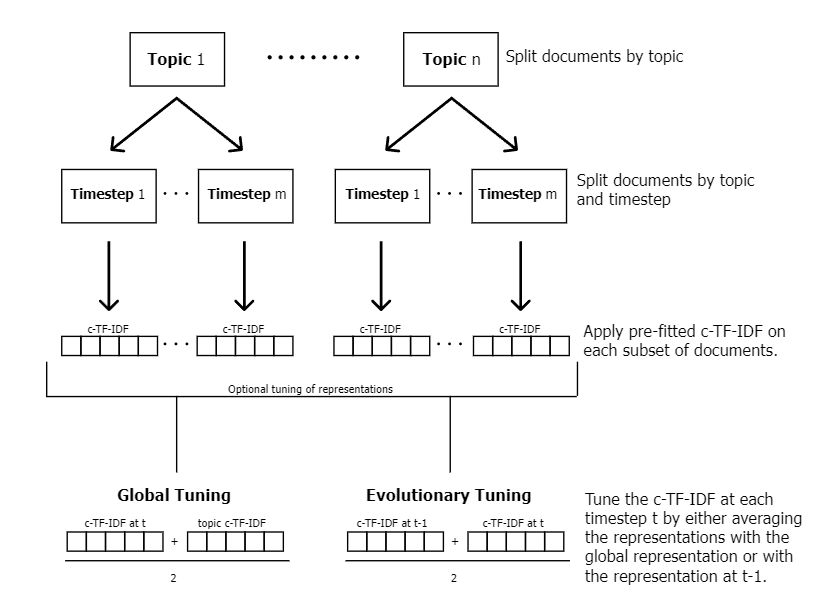

https://maartengr.github.io/BERTopic/getting_started/topicsovertime/topicsovertime.html#parameters

In [ ]:
# First, we need to load the data and do some very basic cleaning. For example, I am not interested in his re-tweets for this use-case:
import re
import pandas as pd

# Prepare data
trump = pd.read_csv('https://drive.google.com/uc?export=download&id=1xRKHaP-QwACMydlDnyFPEaFdtskJuBa6')
trump.text = trump.apply(lambda row: re.sub(r"http\S+", "", row.text).lower(), 1)
trump.text = trump.apply(lambda row: " ".join(filter(lambda x:x[0]!="@", row.text.split())), 1)
trump.text = trump.apply(lambda row: " ".join(re.sub("[^a-zA-Z]+", " ", row.text).split()), 1)
trump = trump.loc[(trump.isRetweet == "f") & (trump.text != ""), :]
timestamps = trump.date.to_list()
tweets = trump.text.to_list()


In [ ]:
pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.0 MB/s eta 0:00:00


In [ ]:
# Extract the global topic representations by simply creating and training a BERTopic model:
from bertopic import BERTopic

topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(tweets)


2024-11-06 22:23:04,137 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1418 [00:00<?, ?it/s]

2024-11-06 22:23:38,760 - BERTopic - Embedding - Completed ✓
2024-11-06 22:23:38,761 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-11-06 22:25:04,747 - BERTopic - Dimensionality - Completed ✓
2024-11-06 22:25:04,750 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-11-06 22:25:14,229 - BERTopic - Cluster - Completed ✓
2024-11-06 22:25:14,253 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-11-06 22:25:15,829 - BERTopic - Representation - Completed ✓


In [ ]:

topics_over_time = topic_model.topics_over_time(tweets, timestamps, nr_bins=20)


20it [00:14,  1.36it/s]


In [ ]:
# Tuning
topics_over_time = topic_model.topics_over_time(tweets, timestamps,
                                                global_tuning=True, evolution_tuning=True, nr_bins=20)


20it [00:34,  1.75s/it]


In [ ]:
# Bins
#If you have more than 100 unique timestamps, then there will be topic representations created for each of those timestamps which can negatively affect the topic representations. It is advised to keep the number of unique timestamps below 50. To do this, you can simply set the number of bins that are created when calculating the topic representations. The timestamps will be taken and put into equal-sized bins:
topics_over_time = topic_model.topics_over_time(tweets, timestamps, nr_bins=20)

20it [00:32,  1.63s/it]


In [ ]:
# Datetime format
topics_over_time = topic_model.topics_over_time(tweets, timestamps, datetime_format="%Y-%m-%d %H:%M:%S", nr_bins=20)

20it [00:18,  1.11it/s]


In [ ]:
#Visualization
# show the top 20 most frequent topics
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=20)

In [ ]:
# show specific topics:topics
topic_model.visualize_topics_over_time(topics_over_time, topics=[9, 10, 72, 83, 87, 91])

# How to evaluate the topic

https://github.com/MIND-Lab/OCTIS?tab=readme-ov-file#evaluate-a-model

https://colab.research.google.com/github/MIND-Lab/OCTIS/blob/master/examples/OCTIS_LDA_training_only.ipynb#scrollTo=HcX6HdBFiaau

#**TopicGPT**

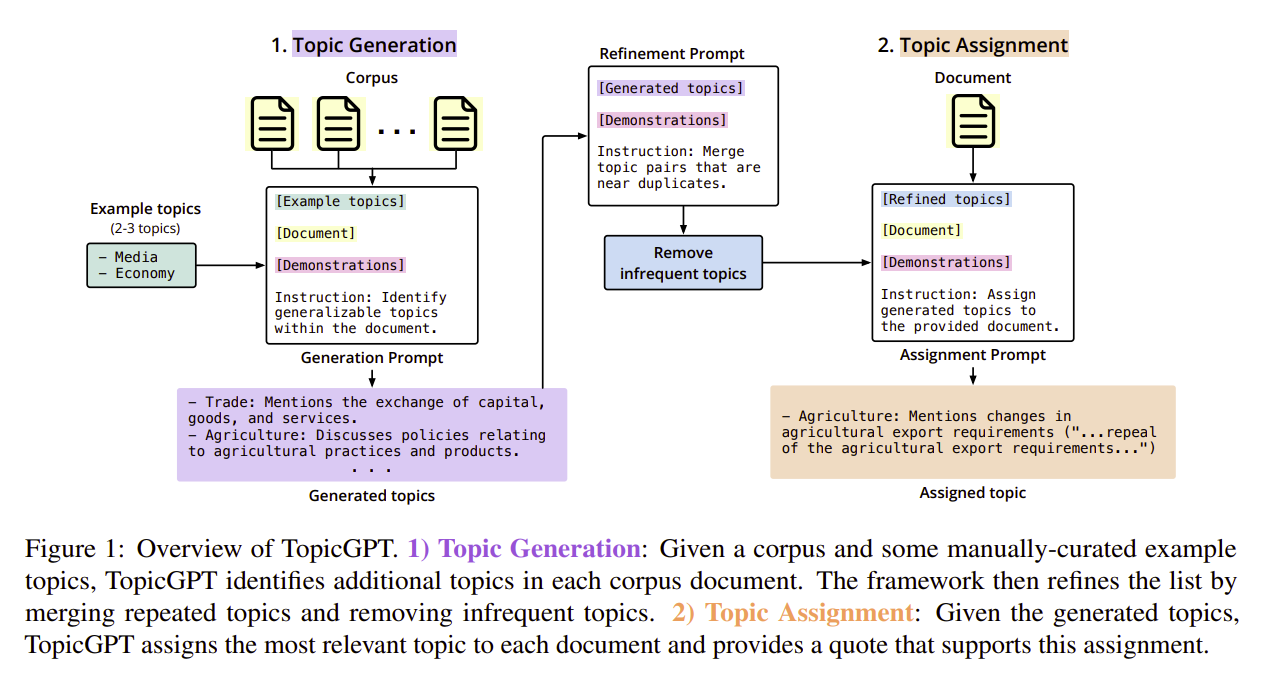

Pham, C. M., Hoyle, A., Sun, S., Resnik, P., & Iyyer, M. (2023). Topicgpt: A prompt-based topic modeling framework. arXiv preprint arXiv:2311.01449.

prompt： https://github.com/chtmp223/topicGPT/tree/main/prompt

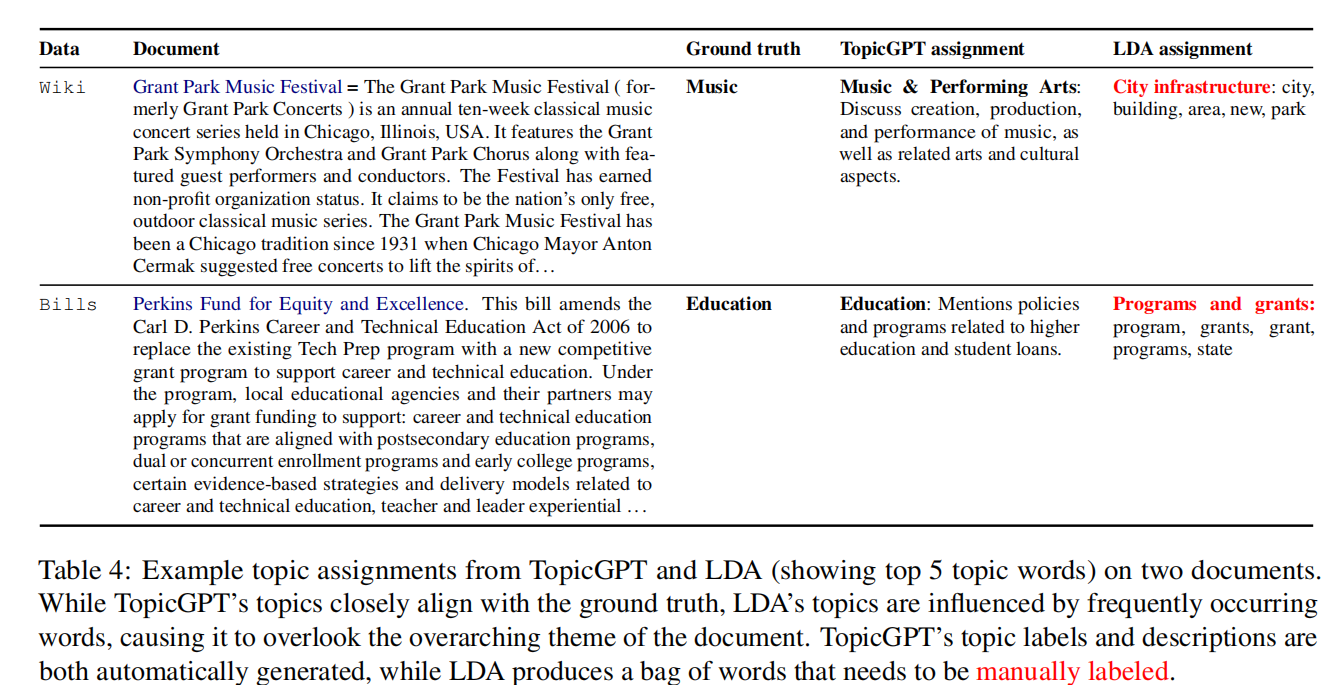

dataset:
{"id":"111-HR-3692","text":"National Forest Roadless Area Conservation Act - Identifies roadless areas within the National Forest System set forth in specified maps as National Forest Inventoried Roadless Areas, and directs the Secretary of Agriculture to manage such Areas to maintain their roadless character. Authorizes the Forest Service to modify such maps for the sole purpose of improving their accuracy or inclusiveness. Requires any substantial modification of those maps to be made through the national forest management planning process and documented in an environmental impact statement.","label":"Public Lands"}
{"id":"111-S-1388","text":"Spokane Tribe of Indians of the Spokane Reservation Grand Coulee Dam Equitable Compensation Settlement Act - (Sec. 3) States that the purpose of this Act is to compensate the Spokane Tribe of Indians of the Spokane Reservation, Washington State for the use of its land for hydropower generation by the Grand Coulee Dam. (Sec. 5) Establishes in the Treasury the Spokane Tribe of Indians Settlement Fund. Authorizes the Spokane Business Council, upon a Fund deposit, to notify the Secretary requesting that the Secretary pay all or a portion of the Fund amounts to the Council. Obligates Fund amounts for: (1) a Cultural Resource Repository and Interpretive Center concerning the culture and history of the Tribe; (2) tribal member benefits; and (3) resource development, credit, scholarship, or educational programs. (Sec. 6) Directs the Administrator of the Bonneville Power Administration (or the head of a successor entity that markets power produced at the Grand Coulee Dam) to pay to the Tribe: (1) on March 1, 2010, 29% of the computed annual payment for FY2009; and (2) on March 1 of each subsequent year, 29% of the computed annual payment for the preceding fiscal year. (Sec. 7) Allows payments made to the Council or Tribe to be used or invested by the Council in the same manner and for the same purposes as other Tribe governmental funds. Provides that: (1) neither the Secretary of the Interior nor the Administrator shall have trust responsibility for the investment, administration, or expenditure of any funds after the date on which the funds are paid to the Council or Tribe; (2) the payments of all funds to the Council and Tribe and the interest and income generated by the funds, shall be treated in the same manner as specified payments under the Saginaw Chippewa Indian Tribe of Michigan Distribution of Judgment Funds Act; and (3) after the date of fund transfer to the Council or Tribe the funds shall be Tribe governmental funds and subject to annual tribal government audit. (Sec. 8) Sets forth repayment credit provisions. (Sec. 9) Directs the Secretary to transfer administrative jurisdiction from the Bureau of Reclamation to the Bureau of Indian Affairs (BIA) over certain land located within the exterior boundaries of the Spokane Indian Reservation. Provides, with regard to land transferred under this section that: (1) such land shall be held in trust for the Tribe and shall remain part of the Spokane Indian Reservation; (2) the federal trust responsibility shall be the same as for other tribal land held in trust within the Spokane Indian Reservation; (3) the United States reserves a perpetual right over such land to carry out the Columbia Basin Project; and (4) land that was included in the Lake Roosevelt National Recreation Area shall remain part of the Recreation Area. States that nothing in this section establishes or affects the boundary between the Spokane Indian Reservation and the Colville Reservation along the Columbia River and Lake Roosevelt or the agreements and rights provided for in the Act of June 29, 1940. (Sec. 10) Provides that payments by the Secretary and the Administrator and restoration of ownership of land in trust constitute full satisfaction of the claim of the Tribe to a fair share of the annual hydropower revenues generated by the Grand Coulee Dam project for the past and continued use of land of the Tribe for the production of hydropower at Grand Coulee Dam. (Sec. 11) Authorizes appropriations to carry out this Act. (Sec. 12) States that nothing in this Act establishes any precedent or is binding on the Southwestern Power Administration, Western Area Power Administration, or Southeastern Power Administration.","label":"Public Lands"}
{"id":"113-S-96","text":"Rigs to Reefs Habitat Protection Act - Directs the Secretary of the Interior to assess each offshore oil and gas platform in the Gulf of Mexico that is no longer useful for operations, and has become critical for a marine fisheries habitat, to: (1) determine whether there are coral populations or other protected species in the platform's vicinity, and (2) identify any species in the vicinity that have recreational or commercial value.\n\nProhibits the removal of any such platforms until the Secretary has completed each assessment.\n\nRequires suspension of the decommissioning of a platform if a substantial reef ecosystem is in the vicinity until the Secretary determines that decommissioning would not harm the ecosystem.\n\nExempts from certain platform removal deadlines any lessees who: (1) commit to entering a particular platform in the artificial reef program under the National Fishing Enhancement Act of 1984, and (2) initiate discussions with applicable states regarding potential artificial reef sites.\n\nAllows a lessee to provide for reefing in place under the artificial reef program.\n\nPermits states with a state rig-to-reef program to enter agreements with any appropriate entities to assume liability in federal water for a structure covered by the state program.\n\nEstablishes a Reef Maintenance Fund. Requires the owner of a rig enrolled in the artificial reef program to: (1) maintain a rig anode system; and (2) pay into the Fund 50% of the estimated platform removal costs for which the owner would have been responsible if it had not participated in the program.","label":"Energy"}
{"id":"112-HR-1395","text":"Leading and Expediting Aerotropolis Development Act of 2011 - Directs the Secretary of Transportation to establish an aerotropolis grant program to assist in the development of aerotropolis transportation systems (i.e., planned and coordinated multimodal freight and passenger transportation networks that provide efficient, sustainable, and intermodal connectivity to a defined region of economic significance centered around a major airport). Authorizes the Secretary to make grants to eligible entities to assist in planning, design, environmental review, or land acquisition activities for one or more specified kinds of projects to benefit such systems.","label":"Transportation"}
